In [1]:
import yaml
import torch
import random
import pickle
import numpy as np
from dotmap import DotMap
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Use matplotlib's tex rendering
import matplotlib
matplotlib.rcParams['text.usetex'] = True

from pud.collector import Collector
from pud.visualize import plot_agent_paths
from pud.vision_agent import LagVisionUVFDDPG
from pud.utils import set_global_seed, set_env_seed
from pud.algos.constrained_collector import ConstrainedCollector
from pud.envs.habitat_navigation_env import GoalConditionedHabitatPointWrapper
from pud.envs.safe_habitatenv.safe_habitat_wrappers import safe_habitat_env_load_fn
from pud.envs.safe_habitatenv.safe_habitat_wrappers import SafeGoalConditionedHabitatPointWrapper, SafeGoalConditionedHabitatPointQueueWrapper
from pud.policies import VisualSearchPolicy, VisualConstrainedSearchPolicy, VisualMultiAgentSearchPolicy, VisualConstrainedMultiAgentSearchPolicy

#### Load the evaluation configuration

In [2]:
unconstrained_ckpt_file = "models/SC2_Staging_08/ckpt/ckpt_0325000"
config_file = "models/SC2_Staging_08/lag/2024-09-11-19-42-08/bk/config.yaml"
illustration_pb_file = "pud/envs/safe_habitatenv/illustration_set/SC2_Staging_08.txt"
constrained_ckpt_file = "models/SC2_Staging_08/lag/2024-09-11-19-42-08/ckpt/ckpt_0255000"

with open(config_file, 'r') as f:
    config = yaml.safe_load(f)
config = DotMap(config)

# User defined parameters for evaluation
config.device = "cuda:0"
config.agent_cost_kwargs.cost_limit = 2.0
config.replay_buffer.max_size = 1000

set_global_seed(config.seed)

#### Load the evaluation environment

In [3]:
gym_env_wrappers = []
gym_env_wrapper_kwargs = []
for wrapper_name in config.wrappers:
    if wrapper_name == "GoalConditionedHabitatPointWrapper":
        gym_env_wrappers.append(GoalConditionedHabitatPointWrapper)
        gym_env_wrapper_kwargs.append(config.wrappers[wrapper_name].toDict())
    elif wrapper_name == "SafeGoalConditionedHabitatPointWrapper":
        gym_env_wrappers.append(SafeGoalConditionedHabitatPointWrapper)
        gym_env_wrapper_kwargs.append(config.wrappers[wrapper_name].toDict())
    elif wrapper_name == "SafeGoalConditionedHabitatPointQueueWrapper":
        gym_env_wrappers.append(SafeGoalConditionedHabitatPointQueueWrapper)
        gym_env_wrapper_kwargs.append(config.wrappers[wrapper_name].toDict())

eval_env = safe_habitat_env_load_fn(
    env_kwargs=config.env.toDict(),
    cost_f_args=config.cost_function.toDict(),
    cost_limit=config.agent_cost_kwargs.cost_limit,
    max_episode_steps=config.time_limit.max_episode_steps,
    gym_env_wrappers=gym_env_wrappers,  # type: ignore
    wrapper_kwargs=gym_env_wrapper_kwargs,
    terminate_on_timeout=True,
    )
set_env_seed(eval_env, config.seed + 2)

Renderer: NVIDIA GeForce RTX 4090/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 550.107.02
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-size-in-bits
[INFO] Calling the APSP construction function


[02:30:02:863307]:[Error]:[Metadata] SceneDatasetAttributesManager.cpp(304)::validateMap : `navmesh_instances` Value : `navmeshes/Baked_sc4_staging_00.navmesh` not found on disk as absolute path or relative to `external_data/replica_cad/replica_cad_baked_lighting`
[02:30:02:863324]:[Error]:[Metadata] SceneDatasetAttributesManager.cpp(304)::validateMap : `navmesh_instances` Value : `navmeshes/Baked_sc4_staging_01.navmesh` not found on disk as absolute path or relative to `external_data/replica_cad/replica_cad_baked_lighting`
[02:30:02:863329]:[Error]:[Metadata] SceneDatasetAttributesManager.cpp(304)::validateMap : `navmesh_instances` Value : `navmeshes/Baked_sc4_staging_02.navmesh` not found on disk as absolute path or relative to `external_data/replica_cad/replica_cad_baked_lighting`
[02:30:02:863333]:[Error]:[Metadata] SceneDatasetAttributesManager.cpp(304)::validateMap : `navmesh_instances` Value : `navmeshes/Baked_sc4_staging_03.navmesh` not found on disk as absolute path or relativ

  0%|          | 0/189 [00:00<?, ?it/s]

APSP construction time in (s):  0.020613908767700195
[INFO] Skipping the reset in HabitatNavigationEnv.__init__ because setup is not ready yet
[INFO] SafeHabitatNavigationEnv Setup: 0.007393598556518555 s


#### Load the inference agent

In [4]:
config.agent["action_dim"] = eval_env.action_space.shape[0]  # type: ignore
config.agent["max_action"] = float(eval_env.action_space.high[0])  # type: ignore

agent = LagVisionUVFDDPG(
    width=config.env.simulator_settings.width,
    height=config.env.simulator_settings.height,
    in_channels=4,
    act_fn=torch.nn.SELU,
    encoder="VisualEncoder",
    device=config.device,
    **config.agent.toDict(),
    cost_kwargs=config.agent_cost_kwargs.toDict(),
)

if len(constrained_ckpt_file) > 0:
    agent.load_state_dict(torch.load(constrained_ckpt_file, map_location=config.device))
else:
    agent.load_state_dict(torch.load(unconstrained_ckpt_file, map_location=config.device))
agent.to(torch.device(config.device))
agent.eval()

LagVisionUVFDDPG(
  (actor): VisualGoalConditionedActor(
    (encoder): VisualEncoder(
      (conv_net): Sequential(
        (0): Conv2d(4, 16, kernel_size=(8, 8), stride=(4, 4))
        (1): SELU()
        (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(4, 4))
        (3): SELU()
        (4): Flatten(start_dim=1, end_dim=-1)
      )
      (l1): Linear(in_features=128, out_features=256, bias=True)
    )
    (l1): Linear(in_features=512, out_features=256, bias=True)
    (l2): Linear(in_features=256, out_features=256, bias=True)
    (l3): Linear(in_features=256, out_features=2, bias=True)
  )
  (actor_target): VisualGoalConditionedActor(
    (encoder): VisualEncoder(
      (conv_net): Sequential(
        (0): Conv2d(4, 16, kernel_size=(8, 8), stride=(4, 4))
        (1): SELU()
        (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(4, 4))
        (3): SELU()
        (4): Flatten(start_dim=1, end_dim=-1)
      )
      (l1): Linear(in_features=128, out_features=256, bias=True)
    )
    (l

#### Sample a replay buffer to form our search graph

In [5]:
rb_vec_grid, rb_vec_visual = ConstrainedCollector.sample_initial_unconstrained_states(eval_env, config.replay_buffer.max_size, habitat=True)

agent.load_state_dict(torch.load(unconstrained_ckpt_file, map_location=config.device))
unconstrained_pdist = agent.get_pairwise_dist(rb_vec_visual, aggregate=None)  # type: ignore
unconstrained_pcost = agent.get_pairwise_cost(rb_vec_visual, aggregate=None)  # type: ignore

agent.load_state_dict(torch.load(constrained_ckpt_file, map_location=config.device))
constrained_pdist = agent.get_pairwise_dist(rb_vec_visual, aggregate=None)  # type: ignore

if len(constrained_ckpt_file) > 0:
    agent.load_state_dict(torch.load(constrained_ckpt_file, map_location=config.device))
else:
    agent.load_state_dict(torch.load(unconstrained_ckpt_file, map_location=config.device))

#### Sample (start, goal) problems for the agent

In [6]:
illustration_problems = pickle.load(open("pud/plots/data/illustration_pbs.pkl", "rb"))

In [7]:

problem = {"start": pbs[0]["start"], "goal": pbs[0]["goal"]}
eval_env.set_use_q(True)  # type: ignore
eval_env.set_prob_constraint(1.0)  # type: ignore
problems = [problem]
eval_env.set_pbs(pb_list=problems.copy())

NameError: name 'pbs' is not defined

In [8]:
from pud.envs.safe_pointenv.pb_sampler import sample_pbs_by_agent, load_pb_set


if len(illustration_pb_file) > 0:
    problems = load_pb_set(file_path=illustration_pb_file, env=eval_env, agent=agent)  # type: ignore
else:
    problems = sample_pbs_by_agent(
        K=10,
        min_dist=0,
        agent=agent,  # type: ignore
        env=eval_env,  # type: ignore
        target_val=10,
        num_states=100,
        ensemble_agg="mean",
        use_uncertainty=False,
        max_dist=eval_env.max_goal_dist,  # type: ignore
    )
    assert len(problems) > 0

# problems = problems[-1:]
eval_env.set_use_q(True)  # type: ignore
eval_env.set_prob_constraint(1.0)  # type: ignore
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

In [9]:
def add_inset_axes(fig, ax, ax_index, eval_env, start, goal, obs, wps=None, agent_id=0, start_point=0.13, side_factor=0.19, xlim=(10, 20), ylim=(9, 18)):
    height, width = eval_env.get_map_height(), eval_env.get_map_width()
    # cost_map = binary_dilation(eval_env.get_map() == 1, structure=np.ones((3,3)), iterations=1)
    axs_inset = fig.add_axes([start_point + ax_index * side_factor, -0.1, 0.15, 0.4])
    im = np.asarray(Image.open("pud/plots/figures/paper/sc2_staging_08.png"))
    axs_inset.imshow(im, extent=[0, height+2, 0, width-2])
    # axs_inset.imshow(eval_env.get_map()[:, ::-1].T, cmap="binary", interpolation="nearest", alpha=0.5, extent=[0, height, 0, width])
    # axs_inset.imshow(cost_map[:, ::-1].T, cmap="hot_r", interpolation="nearest", alpha=0.5, extent=[0, height, 0, width])
    axs_inset.set_xticks([])
    axs_inset.set_yticks([])
    axs_inset.set_xlim(*xlim)
    axs_inset.set_ylim(*ylim)
    axs_inset = plot_agent_paths(agent_id, start, goal, obs, "", axs_inset, wps=wps, use_agent_id=False)
    return axs_inset

## Single-Agent Comparisons

### Unconstrained Low-Level Policy

In [10]:
agent.load_state_dict(torch.load(unconstrained_ckpt_file))
agent.to(torch.device(config.device))
agent.eval()

eval_env.duration = 300  # type: ignore
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore
start, goal, unconstrained_observations, _, _, _ = Collector.get_trajectory(agent, eval_env, habitat=True)

### Unconstrained Low-Level Policy with Graph Search

In [11]:
eval_env.duration = 300  # type: ignore
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

search_policy = VisualSearchPolicy(agent, (rb_vec_grid, rb_vec_visual), pdist=unconstrained_pdist, open_loop=True, max_search_steps=3, no_waypoint_hopping=True)
start, goal, unconstrained_search_observations, unconstrained_search_waypoints, _, _ = Collector.get_trajectory(search_policy, eval_env, habitat=True, input_start=start, input_goal=goal)

/home/mers-pluto/Desktop/Work/Multi_Agent_Research/Hierarchical_Constrained_SORB/cc-sorb-rev/pud/vision_agent.py:328: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /opt/conda/conda-bld/pytorch_1712608883701/work/torch/csrc/utils/tensor_new.cpp:274.)
  observation=torch.FloatTensor(state['observation']),


### Constrained Low-Level Policy

In [12]:
agent.load_state_dict(torch.load(constrained_ckpt_file, map_location=config.device))
agent.to(torch.device(config.device))
agent.eval()

eval_env.duration = 300  # type: ignore
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

start, goal, constrained_observations, _, _, _ = ConstrainedCollector.get_trajectory(agent, eval_env, habitat=True)

### Constrained Low-Level Policy with Graph Search

In [13]:
eval_env.duration = 300  # type: ignore
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

ckpts = {"unconstrained": unconstrained_ckpt_file, "constrained": constrained_ckpt_file}
constrained_search_policy = VisualConstrainedSearchPolicy(agent, (rb_vec_grid, rb_vec_visual), pdist=constrained_pdist, pcost=unconstrained_pcost, ckpts=ckpts, open_loop=True, no_waypoint_hopping=True, max_search_steps=3, max_cost_limit=config.agent_cost_kwargs.cost_limit)
start, goal, constrained_search_observations, constrained_search_waypoints, _, _ = ConstrainedCollector.get_trajectory(constrained_search_policy, eval_env, habitat=True)

#### Plot the single-agent comparison

In [14]:
height, width = 1.0, 1.0
normalization_factor = np.array([height, width])

start_image = start[1]
goal_image = goal[1]
start = start[0] / normalization_factor
goal = goal[0] / normalization_factor

unconstrained_observations = np.array([obs[0] / normalization_factor for obs in unconstrained_observations])
unconstrained_search_observations = np.array([obs[0] / normalization_factor for obs in unconstrained_search_observations])
unconstrained_search_waypoints = np.array([wp[0] / normalization_factor for wp in unconstrained_search_waypoints])

constrained_observations = np.array([obs[0] / normalization_factor for obs in constrained_observations])

constrained_search_image_observations = np.array([obs[1] for obs in constrained_search_observations])
constrained_search_image_waypoints = np.array([wp[1].cpu() for wp in constrained_search_waypoints])
constrained_search_observations = np.array([obs[0] / normalization_factor for obs in constrained_search_observations])
constrained_search_waypoints = np.array([wp[0] / normalization_factor for wp in constrained_search_waypoints])

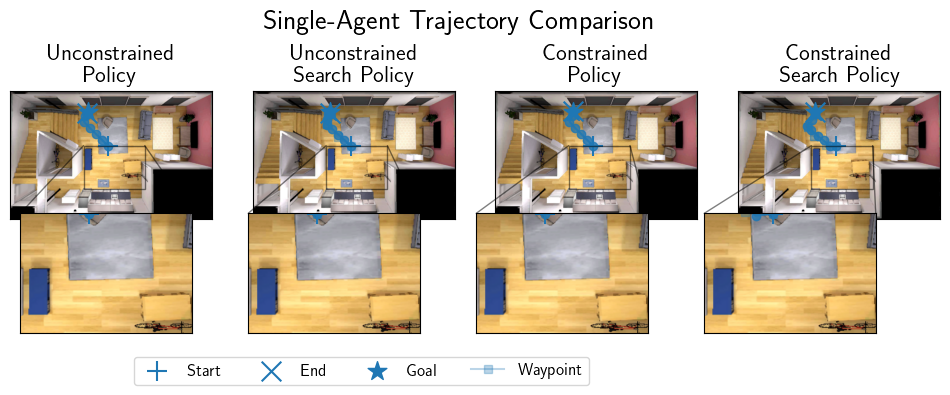

In [16]:
fig, axs = plt.subplots(1, 4, figsize=(12, 3))
height, width = eval_env.get_map_height(), eval_env.get_map_width()

# cost_map = binary_dilation(eval_env.get_map() == 1, structure=np.ones((3,3)), iterations=1)
from PIL import Image
for ax in axs:
    im = np.asarray(Image.open("pud/plots/figures/paper/sc2_staging_08.png"))
    ax.imshow(im, extent=[0, height+1, 0, width+3])
    # ax.imshow(eval_env.get_map()[:, ::-1].T, cmap="binary", interpolation="nearest", alpha=0.5, extent=[0, height, 0, width])
    # cmap = ax.imshow(cost_map[:, ::-1].T, cmap="hot_r", interpolation="nearest", alpha=0.5, extent=[0, height, 0, width])
    ax.set_xticks([])
    ax.set_yticks([])
    
# cbar = plt.colorbar(cmap, ax=axs, orientation="vertical", fraction=0.01, pad=0.04)
# cbar.ax.tick_params(size=0)
# cbar.set_ticks([0, 1, 2])

axs[0] = plot_agent_paths(0, start, goal, unconstrained_observations, "Unconstrained\nPolicy", axs[0], use_agent_id=False)
axs_0_inset = add_inset_axes(fig, axs[0], 0, eval_env, start, goal, unconstrained_observations, xlim=(12, 22), ylim=(5, 12))
axs[0].indicate_inset_zoom(axs_0_inset, edgecolor="black")

axs[1] = plot_agent_paths(0, start, goal, unconstrained_search_observations, "Unconstrained\nSearch Policy", axs[1], wps=unconstrained_search_waypoints, use_agent_id=False)
axs_1_inset = add_inset_axes(fig, axs[1], 1, eval_env, start, goal, unconstrained_search_observations, wps=unconstrained_search_waypoints, xlim=(12, 22), ylim=(5, 12))
axs[1].indicate_inset_zoom(axs_1_inset, edgecolor="black")

axs[2] = plot_agent_paths(0, start, goal, constrained_observations, "Constrained\nPolicy", axs[2], use_agent_id=False)
axs_2_inset = add_inset_axes(fig, axs[2], 2, eval_env, start, goal, constrained_observations, xlim=(12, 22), ylim=(5, 12))
axs[2].indicate_inset_zoom(axs_2_inset, edgecolor="black")

axs[3] = plot_agent_paths(0, start, goal, constrained_search_observations, "Constrained\nSearch Policy", axs[3], wps=constrained_search_waypoints, use_agent_id=False)
axs_3_inset = add_inset_axes(fig, axs[3], 3, eval_env, start, goal, constrained_search_observations, wps=constrained_search_waypoints, xlim=(12, 22), ylim=(5, 12))
axs[3].indicate_inset_zoom(axs_3_inset, edgecolor="black")

# cbar.set_label("Cost")
plt.legend(loc="lower center", bbox_to_anchor=(-2.0, -0.5), ncol=4, fontsize=12)
_ = plt.suptitle("Single-Agent Trajectory Comparison", fontsize=20)
# plt.savefig("pud/plots/figures/paper/single_agent_habitatenv_comparison.svg", bbox_inches="tight")

### Illustrative Habitat Example

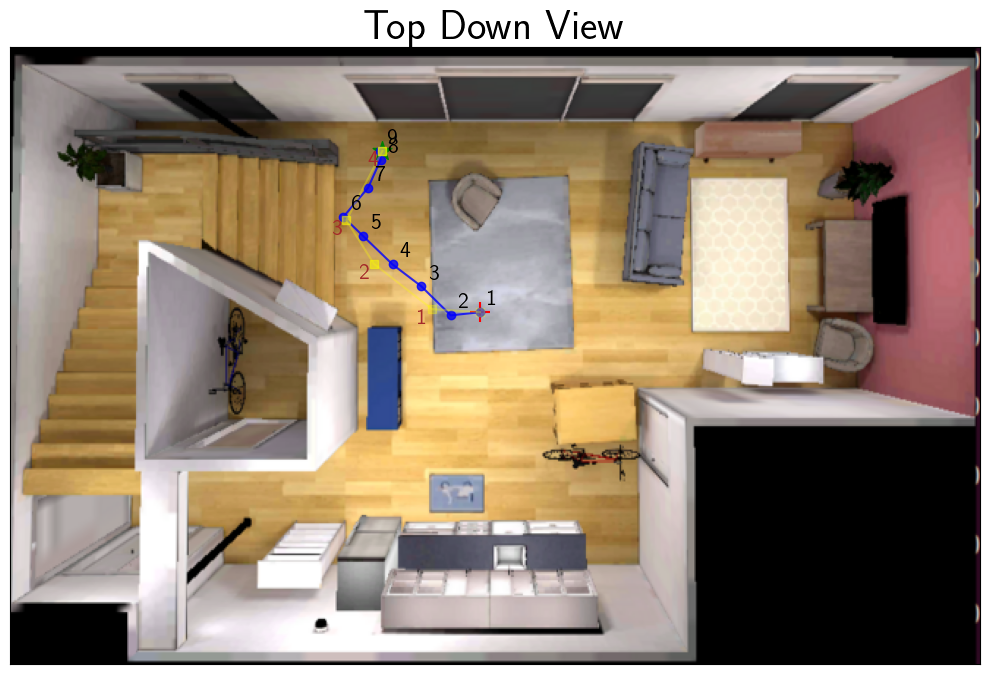

In [19]:
# Extract unique waypoints
constrained_search_image_waypoints_reshaped = constrained_search_image_waypoints.reshape(constrained_search_image_waypoints.shape[0], -1)
unique_waypoints, indices = np.unique(constrained_search_image_waypoints_reshaped, axis=0, return_index=True)
unique_waypoints = constrained_search_image_waypoints[indices[::-1]]

image_direction = 0
fig, ax = plt.subplots(figsize=(10, 7))

# # Load an image from file
from PIL import Image
im = np.asarray(Image.open("pud/plots/figures/paper/sc2_staging_08.png"))
ax.imshow(im, extent=[0, height+1, 0, width+3])

obs = constrained_search_observations
ax.plot(obs[:, 0], obs[:, 1], "o-", c='blue', alpha=0.8)
ax.scatter([start[0]], [start[1]], marker="+", c='red', s=200)
ax.scatter([goal[0]], [goal[1]], marker="*", c="green", s=200)
ax.plot([start[0], *constrained_search_waypoints[:, 0]], [start[1], *constrained_search_waypoints[:, 1]], "s-", c="yellow", alpha=0.3)

# height, width = eval_env.get_map_height(), eval_env.get_map_width()
# axs_inset = fig.add_axes([0.36, 0.58, 0.9, 0.3]) # type: ignore
# axs_inset.imshow(im, extent=[0, height+1, 0, width+3])
# axs_inset.set_xticks([])
# axs_inset.set_yticks([])
# axs_inset.set_xlim((11, 18))
# axs_inset.set_ylim((11, 18))
# ax.indicate_inset_zoom(axs_inset, edgecolor="black")
# obs = constrained_search_observations
# axs_inset.plot(obs[:, 0], obs[:, 1], "o-", c='blue', alpha=0.8)
for i, label in enumerate(range(1, len(obs) + 1)):
    ax.text(obs[i, 0]+0.25, obs[i, 1]+0.25, label, color='black', fontsize=16, weight='bold') # type: ignore

# axs_inset.scatter([start[0]], [start[1]], marker="+", c='red', s=200)
# axs_inset.scatter([goal[0]], [goal[1]], marker="*", c="green", s=200)
# axs_inset.plot([start[0], *constrained_search_waypoints[:, 0]], [start[1], *constrained_search_waypoints[:, 1]], "s-", c="yellow", alpha=0.3)
unique_waypoints_locations = constrained_search_waypoints[indices[::-1]]
for i, label in enumerate(range(1, unique_waypoints.shape[0]+1)):
    ax.text(unique_waypoints_locations[i, 0]-0.5, unique_waypoints_locations[i, 1]-0.5, label, color='brown', fontsize=16, weight='bold') # type: ignore
ax.set_title("Top Down View", fontsize=30, weight='bold')
ax.set_xticks([])
ax.set_yticks([])
    
plt.tight_layout()
plt.savefig("pud/plots/figures/paper/visual_navigation_approach_top_down.svg", bbox_inches="tight")

/tmp/ipykernel_247779/2740387513.py:84: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()


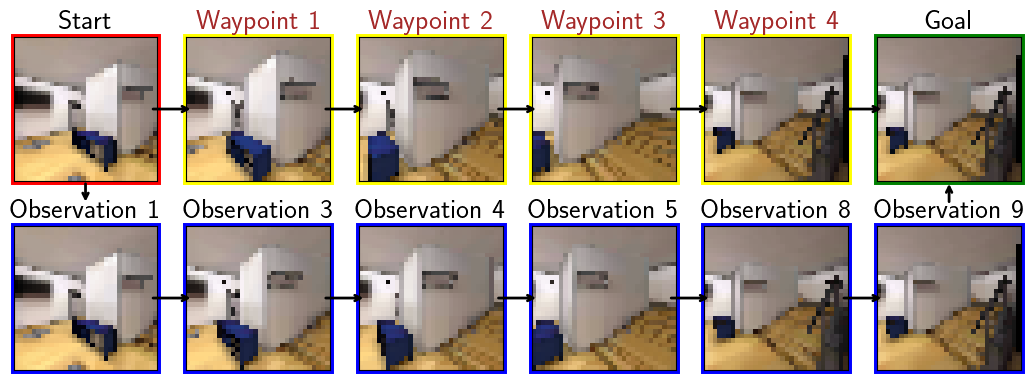

In [26]:
# Extract unique waypoints
constrained_search_image_waypoints_reshaped = constrained_search_image_waypoints.reshape(constrained_search_image_waypoints.shape[0], -1)
unique_waypoints, indices = np.unique(constrained_search_image_waypoints_reshaped, axis=0, return_index=True)
unique_waypoints = constrained_search_image_waypoints[indices[::-1]]

image_direction = 0
fig = plt.figure(figsize=(13, 4.5))
max_images_in_row = min(6, constrained_search_image_observations.shape[0])
gs = gridspec.GridSpec(2, max_images_in_row, height_ratios=[1, 1])


# Observations at the bottom!
if constrained_search_image_observations.shape[0] > max_images_in_row:
    observations_to_show = sorted(random.sample(range(constrained_search_image_observations.shape[0]), max_images_in_row))
    constrained_search_image_observations = constrained_search_image_observations[observations_to_show]

bottom_row = []
for i in range(max_images_in_row):
    ax = fig.add_subplot(gs[1, i])
    ax.imshow(constrained_search_image_observations[i][image_direction])
    ax.set_title(f"Observation {observations_to_show[i]+1}", weight='bold',  fontsize=20)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.patch.set_linewidth(5)   # type: ignore
    ax.patch.set_edgecolor('blue')   # type: ignore
    bottom_row.append(ax)


top_row = []
# Start image
ax = fig.add_subplot(gs[0, 0])
ax.imshow(start_image[image_direction])
ax.set_title("Start", weight='bold', fontsize=20)
ax.set_xticks([])
ax.set_yticks([])
ax.patch.set_linewidth(5) # type: ignore
ax.patch.set_edgecolor('red')   # type: ignore
top_row.append(ax)

# Waypoint images at the top
if unique_waypoints.shape[0] > max_images_in_row // 2 + 1:
    waypoints_to_show = sorted(random.sample(range(unique_waypoints.shape[0]), max_images_in_row // 2 + 1))
    unique_waypoints = unique_waypoints[waypoints_to_show]
else:
    waypoints_to_show = range(unique_waypoints.shape[0])
for i in range(max_images_in_row // 2 + 1):
    ax = fig.add_subplot(gs[0, i+1:i+2])  # Third row, all columns
    ax.imshow(unique_waypoints[i][image_direction])
    ax.set_title(f"Waypoint {waypoints_to_show[i]+1}", color="brown", weight='bold', fontsize=20)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.patch.set_linewidth(5)   # type: ignore
    ax.patch.set_edgecolor('yellow')   # type: ignore
    top_row.append(ax)

# Goal image
ax = fig.add_subplot(gs[0, -1])
ax.imshow(goal_image[image_direction])
ax.set_title("Goal", weight='bold', fontsize=20)
ax.set_xticks([])
ax.set_yticks([])
ax.patch.set_linewidth(5)   # type: ignore
ax.patch.set_edgecolor('green')   # type: ignore
top_row.append(ax)

for i in range(len(top_row) - 1):
    ax_from = top_row[i]
    ax_to = top_row[(i+1) % len(top_row)]
    plt.annotate("", xy=(0.95, 0.5), xytext=(0.05, 0.5), xycoords=ax_from.transAxes, textcoords=ax_to.transAxes, arrowprops=dict(arrowstyle="<-", color="black", lw=2))

for i in range(len(bottom_row) - 1):
    ax_from = bottom_row[i]
    ax_to = bottom_row[(i+1) % len(bottom_row)]
    plt.annotate("", xy=(0.95, 0.5), xytext=(0.05, 0.5), xycoords=ax_from.transAxes, textcoords=ax_to.transAxes, arrowprops=dict(arrowstyle="<-", color="black", lw=2))

ax_from = top_row[0]
ax_to = bottom_row[0]
plt.annotate("", xy=(0.5, 0.0), xytext=(0.5, 1.15), xycoords=ax_from.transAxes, textcoords=ax_to.transAxes, arrowprops=dict(arrowstyle="<-", color="black", lw=2))

ax_from = top_row[-1]
ax_to = bottom_row[-1]
plt.annotate("", xy=(0.5, 0.0), xytext=(0.5, 1.15), xycoords=ax_from.transAxes, textcoords=ax_to.transAxes, arrowprops=dict(arrowstyle="->", color="black", lw=2))

plt.tight_layout()
# _ = plt.suptitle("Visual Navigation Approach", fontsize=20)
plt.savefig("pud/plots/figures/paper/visual_navigation_approach.svg", bbox_inches="tight")

## Multi-Agent Comparisons

### Unconstrained Low-Level Policy

In [18]:
n_agents = 4
agent.load_state_dict(torch.load(unconstrained_ckpt_file))
agent.to(torch.device(config.device))
agent.eval()

illpbs=[pbs[0], pbs[5], pbs[6], pbs[7]]

eval_env.duration = 300  # type: ignore
eval_env.set_pbs(pb_list=illpbs.copy())  # type: ignore
start, goal, unconstrained_observations, _, _, _ = Collector.get_trajectories(agent, eval_env, n_agents, habitat=True)

### Unconstrained Low-Level Policy with Graph Search

In [19]:
eval_env.duration = 300  # type: ignore
eval_env.set_pbs(pb_list=illpbs.copy())  # type: ignore

ma_search_policy = VisualMultiAgentSearchPolicy(agent, (rb_vec_grid, rb_vec_visual), n_agents, pdist=unconstrained_pdist, open_loop=True, max_search_steps=3, no_waypoint_hopping=True)
start, goal, unconstrained_search_observations, unconstrained_search_waypoints, _, _ = Collector.get_trajectories(ma_search_policy, eval_env, n_agents, habitat=True, input_starts=start, input_goals=goal)

### Constrained Low-Level Policy

In [20]:
agent.load_state_dict(torch.load(constrained_ckpt_file))
agent.to(torch.device(config.device))
agent.eval()

eval_env.duration = 300  # type: ignore
eval_env.set_pbs(pb_list=illpbs.copy())  # type: ignore

start, goal, constrained_observations, _, _, _ = ConstrainedCollector.get_trajectories(agent, eval_env, n_agents, habitat=True)

### Constrained Low-Level Policy with Graph Search

In [21]:
eval_env.duration = 300  # type: ignore
eval_env.set_pbs(pb_list=illpbs.copy())  # type: ignore

# config.agent_cost_kwargs.cost_limit = 5.0

constrained_ma_search_policy = VisualConstrainedMultiAgentSearchPolicy(agent, (rb_vec_grid, rb_vec_visual), n_agents, pdist=constrained_pdist, pcost=unconstrained_pcost, open_loop=True, no_waypoint_hopping=True, max_search_steps=3, max_cost_limit=config.agent_cost_kwargs.cost_limit, ckpts={"unconstrained": unconstrained_ckpt_file, "constrained": constrained_ckpt_file})
start, goal, constrained_search_observations, constrained_search_waypoints, _, _ = ConstrainedCollector.get_trajectories(constrained_ma_search_policy, eval_env, n_agents, habitat=True)

#### Plot the multi-agent comparison

In [22]:
height, width = 1.0, 1.0
normalization_factor = np.array([height, width])

for agent_id in range(n_agents):
    start[agent_id] = start[agent_id][0] / normalization_factor
    goal[agent_id] = goal[agent_id][0] / normalization_factor

    unconstrained_observations[agent_id] = np.array([obs[0] / normalization_factor for obs in unconstrained_observations[agent_id]]) # type: ignore
    unconstrained_search_observations[agent_id] = np.array([obs[0] / normalization_factor for obs in unconstrained_search_observations[agent_id]]) # type: ignore
    unconstrained_search_waypoints[agent_id] = np.array([wp[0] / normalization_factor for wp in unconstrained_search_waypoints[agent_id]]) # type: ignore

    constrained_observations[agent_id] = np.array([obs[0] / normalization_factor for obs in constrained_observations[agent_id]])
    constrained_search_observations[agent_id] = np.array([obs[0] / normalization_factor for obs in constrained_search_observations[agent_id]])
    constrained_search_waypoints[agent_id] = np.array([wp[0] / normalization_factor for wp in constrained_search_waypoints[agent_id]])

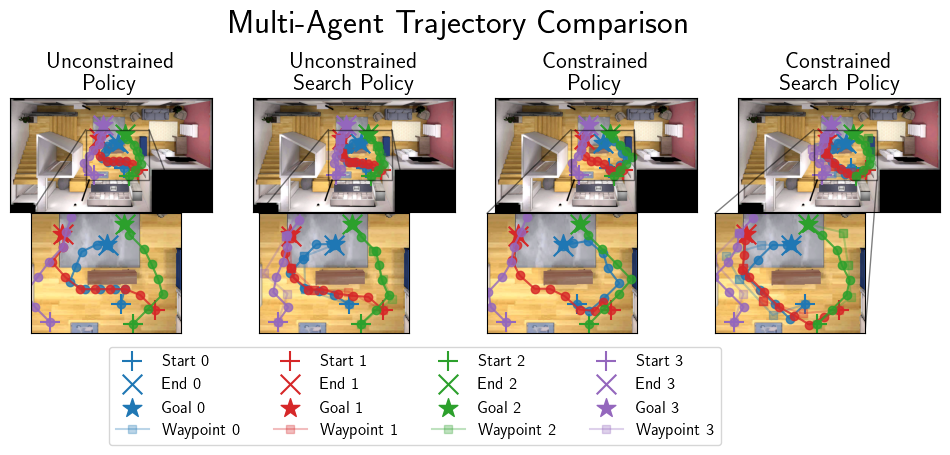

In [44]:
fig, axs = plt.subplots(1, 4, figsize=(12, 3))
height, width = eval_env.get_map_height(), eval_env.get_map_width()

# cost_map = binary_dilation(eval_env.get_map() == 1, structure=np.ones((3,3)), iterations=1)
from PIL import Image
for ax in axs:
    # ax.imshow(eval_env.get_map()[:, ::-1].T, cmap="binary", interpolation="nearest", alpha=0.5, extent=[0, height, 0, width])
    # cmap = ax.imshow(cost_map[:, ::-1].T, cmap="hot_r", interpolation="nearest", alpha=0.5, extent=[0, height, 0, width])
    im = np.asarray(Image.open("pud/plots/figures/paper/sc3_staging_11.png"))
    ax.imshow(im, extent=[0, height, 0, width])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal", adjustable="box")

# cbar = plt.colorbar(cmap, ax=axs, orientation="vertical", fraction=0.01, pad=0.04)
# cbar.ax.tick_params(size=0)
# cbar.set_ticks([0, 1, 2])

for agent_id in range(n_agents):
    agent_unconstrained_observations = np.array(unconstrained_observations[agent_id])
    agent_unconstrained_search_observations = np.array(unconstrained_search_observations[agent_id])
    agent_constrained_observations = np.array(constrained_observations[agent_id])
    agent_constrained_search_observations = np.array(constrained_search_observations[agent_id])
    
    agent_unconstrained_search_waypoints = np.array(unconstrained_search_waypoints[agent_id])
    agent_constrained_search_waypoints = np.array(constrained_search_waypoints[agent_id])

    axs[0] = plot_agent_paths(agent_id, start[agent_id], goal[agent_id], agent_unconstrained_observations, "Unconstrained\nPolicy", axs[0]) 
    axs[1] = plot_agent_paths(agent_id, start[agent_id], goal[agent_id], agent_unconstrained_search_observations, "Unconstrained\nSearch Policy", axs[1], wps=agent_unconstrained_search_waypoints)
    axs[2] = plot_agent_paths(agent_id, start[agent_id], goal[agent_id], agent_constrained_observations, "Constrained\nPolicy", axs[2])
    axs[3] = plot_agent_paths(agent_id, start[agent_id], goal[agent_id], agent_constrained_search_observations, "Constrained\nSearch Policy", axs[3], wps=agent_constrained_search_waypoints)


inset_agent_id = 0

axs_0_inset = add_inset_axes(fig, axs[0], 0, eval_env, start[inset_agent_id], goal[inset_agent_id], np.array(unconstrained_observations[inset_agent_id]), agent_id=inset_agent_id, xlim=(12, 22), ylim=(5, 13))
for n_agent in range(1, n_agents):
    axs_0_inset = plot_agent_paths(n_agent, start[n_agent], goal[n_agent], np.array(unconstrained_observations[n_agent]), "", axs_0_inset, wps=None, use_agent_id=False)
axs[0].indicate_inset_zoom(axs_0_inset, edgecolor="black")

axs_1_inset = add_inset_axes(fig, axs[1], 1, eval_env, start[inset_agent_id], goal[inset_agent_id], np.array(unconstrained_search_observations[inset_agent_id]), agent_id=inset_agent_id, wps=np.array(unconstrained_search_waypoints[inset_agent_id]), xlim=(12, 22), ylim=(5, 13))
for n_agent in range(1, n_agents):
    axs_1_inset = plot_agent_paths(n_agent, start[n_agent], goal[n_agent], np.array(unconstrained_search_observations[n_agent]), "", axs_1_inset, wps=np.array(unconstrained_search_waypoints[n_agent]), use_agent_id=False)
axs[1].indicate_inset_zoom(axs_1_inset, edgecolor="black")

axs_2_inset = add_inset_axes(fig, axs[2], 2, eval_env, start[inset_agent_id], goal[inset_agent_id], np.array(constrained_observations[inset_agent_id]), agent_id=inset_agent_id, xlim=(12, 22), ylim=(5, 13))
for n_agent in range(1, n_agents):
    axs_2_inset = plot_agent_paths(n_agent, start[n_agent], goal[n_agent], np.array(constrained_observations[n_agent]), "", axs_2_inset, wps=None, use_agent_id=False)
axs[2].indicate_inset_zoom(axs_2_inset, edgecolor="black")

axs_3_inset = add_inset_axes(fig, axs[3], 3, eval_env, start[inset_agent_id], goal[inset_agent_id], np.array(constrained_search_observations[inset_agent_id]), wps=np.array(constrained_search_waypoints[inset_agent_id]), agent_id=inset_agent_id, xlim=(12, 22), ylim=(5, 13))
for n_agent in range(1, n_agents):
    axs_3_inset = plot_agent_paths(n_agent, start[n_agent], goal[n_agent], np.array(constrained_search_observations[n_agent]), "", axs_3_inset, wps=np.array(constrained_search_waypoints[n_agent]), use_agent_id=False)
axs[3].indicate_inset_zoom(axs_3_inset, edgecolor="black")

handles, labels = axs[1].get_legend_handles_labels()
plt.legend(handles=handles, labels=labels, loc="lower center", bbox_to_anchor=(-2.0, -1.0), ncol=4, fontsize=12)
_ = plt.suptitle("Multi-Agent Trajectory Comparison", fontsize=24)
plt.savefig("pud/plots/figures/paper/multi_agent_habitatenv_comparison.svg", bbox_inches="tight")